# Imports

In [93]:
import os
import pandas as pd
import spacy
from spacy.tokens import DocBin
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

from spacy.pipeline.textcat import Config, single_label_bow_config
from sklearn.model_selection import train_test_split

# Get data

## GPT

In [94]:
DATABASE_PATH = "data"

In [133]:
df = pd.concat([pd.read_csv(os.path.join(DATABASE_PATH, file)) for file in os.listdir(DATABASE_PATH) if file.endswith('.csv')])

print(f'Questions and answer {len(df)}')
print(f"Perguntas sobre alimentação {len(df[df['pergunta_alimentacao'] == True])}")
print(f"Perguntas sobre medicamento {len(df[df['pergunta_medicamento'] == True])}")
print(f"Perguntas sobre controle glicemico {len(df[df['pergunta_controle_glicemico'] == True])}")
print(f"resposta sobre alimentação {len(df[df['resposta_alimentacao'] == True])}")
print(f"resposta sobre medicamento {len(df[df['pergunta_medicamento'] == True])}")
print(f"resposta sobre controle glicemico {len(df[df['pergunta_controle_glicemico'] == True])}")
print(f"Fonts {len(df['fonte'].unique())}")

Questions and answer 365


KeyError: 'pergunta_alimentacao'

In [96]:
data = []
for _, row in df.iterrows():
    data.append((
        row['pergunta'],
        {
            "cats":{
                "alimentação": 1 if row["pergunta_alimentacao"] else 0,
                "medicamento": 1 if row["pergunta_medicamento"] else 0,
                "controle_glicemico": 1 if row["pergunta_controle_glicemico"] else 0,
            }
        }
    ))

data[0]

('Como posso substituir alimentos ricos em carboidratos refinados por opções de baixo índice glicêmico no almoço?',
 {'cats': {'alimentação': 1, 'medicamento': 0, 'controle_glicemico': 0}})

## Manual

In [167]:
DATABASE_PATH = "data/diabetes_mellitus_quick_guide"

In [172]:
df = pd.concat([pd.read_csv(os.path.join(DATABASE_PATH, file)) for file in os.listdir(DATABASE_PATH) if file.endswith('.csv')])
df


,pergunta,alimentacao,medicamento,controle_glicemico,duvida_geral,resposta,nome_artigo,trecho
0,O que é Diabetes Mellitus segundo o guia?,False,False,False,True,É um grupo de doenças metabólicas marcado por ...,Diabetes Mellitus Quick Guide,…grupo de doenças metabólicas marcado por hipe...
1,Por que a DM é considerada “silenciosa”?,False,False,False,True,Porque mais de 50 % das pessoas não sabem que ...,Diabetes Mellitus Quick Guide,…mais de 50 % dos indivíduos desconhecem ter a...
2,Quantas pessoas têm diabetes no mundo segundo ...,False,False,False,True,Cerca de 537 milhões em 2021.,Diabetes Mellitus Quick Guide,…Atlas IDF 2021: 537 milhões de pessoas vivem ...
3,Em quanto aumentou o número de casos entre 201...,False,False,False,True,Houve um aumento de 74 milhões de casos.,Diabetes Mellitus Quick Guide,…de 463 milhões em 2019 para 537 milhões em 20...
4,Qual porcentagem das mortes no Brasil é causad...,False,False,False,True,As DCNT respondem por 72 % da mortalidade no p...,Diabetes Mellitus Quick Guide,…doenças crônicas não transmissíveis respondem...
...,...,...,...,...,...,...,...,...
5,Qual teste é indicado em caso de dúvida diagnó...,False,False,True,False,TOTG (Teste Oral de Tolerância à Glicose).,Diabetes Mellitus Quick Guide,…teste de tolerância oral à glicose (TOTG)…
6,Quantos exames alterados são necessários para ...,False,False,True,False,Dois exames distintos com resultados alterados.,Diabetes Mellitus Quick Guide,É necessário que haja alteração em dois exames.
7,Qual combinação de exames numa mesma amostra p...,False,False,True,False,"Glicemia de jejum ≥ 126 mg/dL e HbA1c ≥ 6,5 %.",Diabetes Mellitus Quick Guide,"…glicemia de jejum ≥ 126 mg/dL e HbA1c ≥ 6,5 %..."
8,Que situação clínica exige diagnóstico diferen...,False,False,False,True,Apresentações atípicas onde a classificação nã...,Diabetes Mellitus Quick Guide,Exames complementares específicos só devem ser...


In [169]:
print(f'Questions and answer {len(df)}')
print(f"Perguntas sobre alimentação {len(df[df['alimentacao'] == True])}")
print(f"Perguntas sobre medicamento {len(df[df['medicamento'] == True])}")
print(f"Perguntas sobre controle glicemico {len(df[df['controle_glicemico'] == True])}")
print(f"Perguntas sobre controle glicemico {len(df[df['duvida_geral'] == True])}")

Questions and answer 365
Perguntas sobre alimentação 47
Perguntas sobre medicamento 134
Perguntas sobre controle glicemico 178
Perguntas sobre controle glicemico 95


In [170]:
data = []
for _, row in df.iterrows():
    data.append((
        row['pergunta'],
        {
            "cats":{
                "alimentação": 1 if row["alimentacao"] else 0,
                "medicamento": 1 if row["medicamento"] else 0,
                "controle_glicemico": 1 if row["controle_glicemico"] else 0,
                "duvida_geral": 1 if row["duvida_geral"] else 0,
            }
        }
    ))

data[0]

('O que é Diabetes Mellitus segundo o guia?',
 {'cats': {'alimentação': 0,
   'medicamento': 0,
   'controle_glicemico': 0,
   'duvida_geral': 1}})

# separete data

In [183]:
test_size = 0.2
seed = 42

labels = []
for _, info in data:
    cats = info['cats']
    label_tuple = tuple(cats[k] for k in sorted(cats))
    labels.append(label_tuple)


train_data, test_data = train_test_split(
    data,
    test_size=test_size,
    random_state=seed,
    # stratify=labels,
    shuffle=True,
)

In [184]:
def plot_class_proportions(data, title):
    counts = {}
    for _, info in data:
        for cat, val in info['cats'].items():
            counts[cat] = counts.get(cat, 0) + val

    total = len(data)
    proportions = {cat: count for cat, count in counts.items()}

    plt.figure()
    plt.bar(proportions.keys(), proportions.values())
    plt.ylabel('Proporção')
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

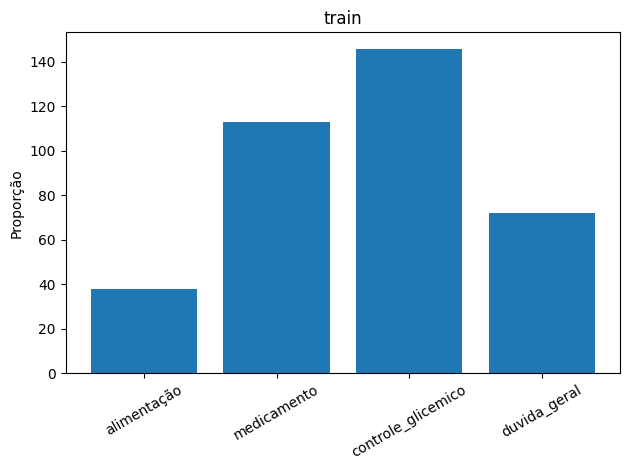

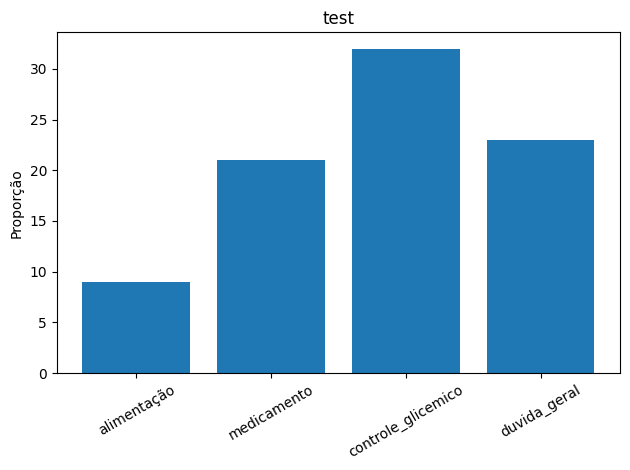

In [185]:
plot_class_proportions(train_data, 'train')
plot_class_proportions(test_data, 'test')

# Model

In [198]:
nlp = spacy.blank('pt')

In [199]:
textcat = nlp.add_pipe(
    "textcat_multilabel",
    config={
        "threshold": 0.8
    }
)
textcat.add_label("alimentação")
textcat.add_label("medicamento")
textcat.add_label("controle_glicemico")
textcat.add_label("duvida_geral")

1

In [200]:
db = DocBin()
for text, annotations in train_data:
    if text is np.nan:
        continue
    print(text)
    doc = nlp.make_doc(text)
    doc.cats = annotations["cats"]
    db.add(doc)
db.to_disk("./train.spacy")

Qual mecanismo causa o DM1?
É obrigatório levar exame de creatinina na renovação?
Qual exame não se recomenda fazer de rotina no diagnóstico de DM segundo o guia?
O diário de glicemias pode ser eletrônico?
Qual exame laboratorial número 1 deve ser acompanhado rotineiramente em pacientes com diabetes?
Quando é indicado usar seringa de 100 U em vez de 30 U ou 50 U?
Que exames de glicemia pós-prandial são aceitos no protocolo?
Qual estratégia ajuda a manter a glicose estável em pacientes usando bomba de insulina?
Qual exame laboratorial número 10 deve ser acompanhado rotineiramente em pacientes com diabetes?
Que siglas e abreviações estão listadas no anexo de siglas?
Médico residente pode assinar a LME?
Quais valores de glicemia 2 h após TOTG sugerem DM?
Qual documento oficial lista todas essas regras de fluxo?
Existe diferença de fluxo para insulina de ação rápida e longa?
Quais critérios de função renal indicam referência para nefrologia?
Como ajustar o tratamento para pessoas que usam 

In [201]:
import random
import spacy
from spacy.tokens import DocBin


random.shuffle(train_data)
split = int(len(train_data) * 0.8)
train_examples = train_data[:split]
dev_examples   = train_data[split:]

def create_spacy_bin(examples, output_path):
    nlp = spacy.blank("pt")
    db = DocBin()
    for text, ann in examples:
        doc = nlp.make_doc(text)
        doc.cats = ann["cats"]
        db.add(doc)
    db.to_disk(output_path)

# Cria os arquivos .spacy
create_spacy_bin(train_examples, "./train.spacy")
create_spacy_bin(dev_examples,   "./dev.spacy")


# Metrics

In [211]:
nlp_final = spacy.load("./output/model-best")
# question = test_data[-1][0]
question = "posso comer macarrão?" 
doc = nlp_final(question)
print(question, doc.cats)

posso comer macarrão? {'alimentação': 0.11827569454908371, 'medicamento': 0.7137566804885864, 'controle_glicemico': 0.21863333880901337, 'duvida_geral': 0.21152999997138977}


In [203]:
import spacy
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    multilabel_confusion_matrix
)
import matplotlib.pyplot as plt

def evaluate_spacy_classifier(model_path, test_data, threshold=0.5):

    nlp = spacy.load(model_path)
    # 2) Prepare texts and true‐labels matrix
    texts = [t for t, ann in test_data]
    label_names = sorted(test_data[0][1]['cats'].keys())
    y_true = np.array([
        [ann['cats'][lbl] for lbl in label_names]
        for _, ann in test_data
    ])
    # 3) Run predictions
    docs = list(nlp.pipe(texts))
    y_scores = np.array([
        [doc.cats[lbl] for lbl in label_names]
        for doc in docs
    ])
    # binarize
    y_pred = (y_scores >= threshold).astype(int)

    # 4) Overall "exact match" accuracy (all labels correct)
    exact_acc = (y_pred == y_true).all(axis=1).mean()
    print(f"Exact‐match accuracy: {exact_acc:.3f}")

    # 5) Micro & Macro precision/recall/f1
    p_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    r_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    p_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    r_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print("Micro‐averaged Precision / Recall / F1:")
    print(f"  P: {p_micro:.3f}, R: {r_micro:.3f}, F1: {f1_micro:.3f}")
    print("Macro‐averaged Precision / Recall / F1:")
    print(f"  P: {p_macro:.3f}, R: {r_macro:.3f}, F1: {f1_macro:.3f}\n")

    # 6) Per‐class report
    print("Per‐class classification report:")
    print(classification_report(
        y_true, y_pred, target_names=label_names, zero_division=0
    ))

    # 7) Confusion matrices and heatmaps
    cms = multilabel_confusion_matrix(y_true, y_pred)
    for idx, cm in enumerate(cms):
        tn, fp, fn, tp = cm.ravel()
        fig, ax = plt.subplots()
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f"Confusion Matrix: {label_names[idx]}")
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Pred 0','Pred 1'])
        ax.set_yticklabels(['True 0','True 1'])
        # annotate counts
        for i in (0,1):
            for j in (0,1):
                ax.text(j, i, cm[i,j],
                        ha='center', va='center')
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
    plt.show()

Exact‐match accuracy: 0.168
Micro‐averaged Precision / Recall / F1:
  P: 0.638, R: 0.384, F1: 0.480
Macro‐averaged Precision / Recall / F1:
  P: 0.598, R: 0.399, F1: 0.426

Per‐class classification report:
                    precision    recall  f1-score   support

       alimentação       0.50      0.04      0.08        73
controle_glicemico       0.72      0.50      0.59        88
       medicamento       0.57      0.65      0.61        55

         micro avg       0.64      0.38      0.48       216
         macro avg       0.60      0.40      0.43       216
      weighted avg       0.61      0.38      0.42       216
       samples avg       0.57      0.41      0.45       216



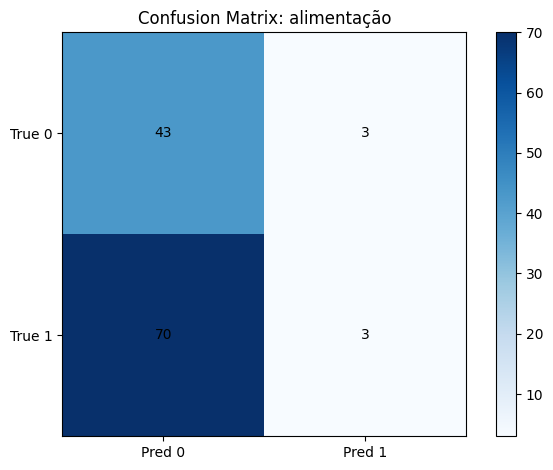

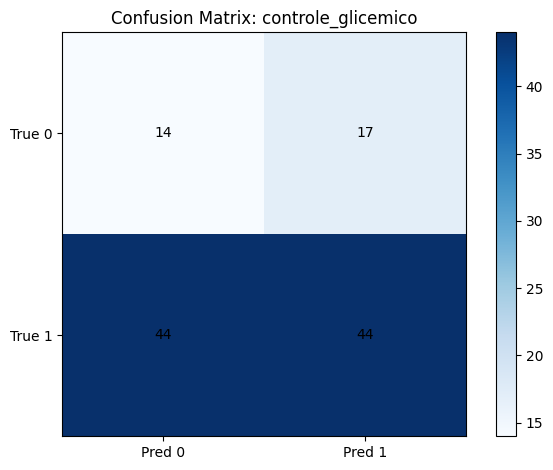

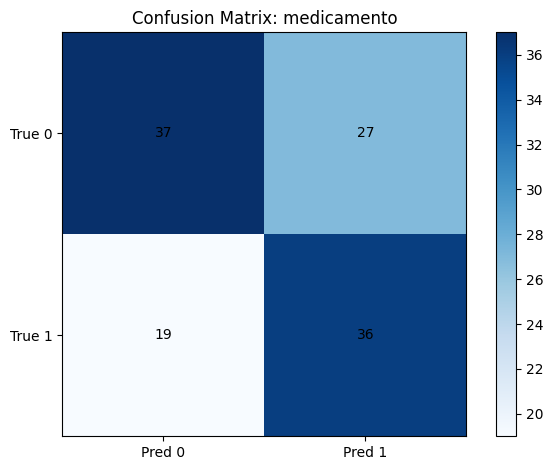

In [214]:
from test_data import data_test
evaluate_spacy_classifier("./output/model-best", data_test, threshold=0.5)